# **Lesson_5.2**

## In this lecture

* Fork repository

* K-means clustering (carried over from the previous lesson)
* Simple and multiple linear regression
* In-class exercise

---

## **Simple** and **multiple** linear regression

* Simple

<p align="center">
	<img src="../assets/img/simple_lin_regr.jpg" width="700">
</p>

* Multiple

<p align="center">
	<img src="../assets/img/multiple_lin_regr_math.jpg" width="700">
</p>

... + error term

---

## Linear regression model for Medical Charges prediction

### Business objectives
* Purpose of the project: Predicting medical expences using Linear Regression
* Business question: what would be medical charges for new customers?

See previous lecture for the EDA

### Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Load data

In [2]:
# Data path
data_path = '../datasets/medical-charges.csv'

# Load data
medical_df = pd.read_csv(data_path)
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### Further EDA: feature correlation

In [ ]:
print(medical_df['charges'].corr(medical_df['age'])) # number between 1-0 that represrst hwo closly the data is linked 
print(medical_df['charges'].corr(medical_df['bmi']))
print(medical_df['charges'].corr(medical_df['children']))

0.2990081933306476
0.19834096883362878
0.06799822684790469


In [ ]:
# Map smoker 'yes'/'no' values
smoker_values = {'no':0, 'yes':1}
smoker_numeric = medical_df['smoker'].map(smoker_values) # uses the var smoker_values to change the collum smoker to 0 or 1 depending on what their strings are  
medical_df['charges'].corr(smoker_numeric) 

np.float64(0.7872514304984782)

* Correlation matrix

In [ ]:
medical_df.select_dtypes(include='number').corr() # feature cannot have a high correlation "include=numbers" excludes string

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


* Heatmap

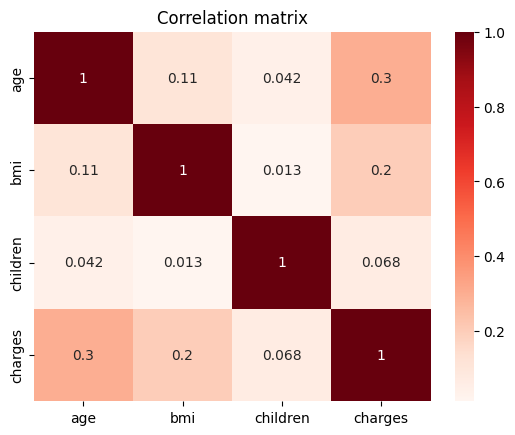

In [ ]:
sns.heatmap(
    medical_df.select_dtypes(include='number').corr(),
    cmap='Reds',
    annot=True  # If True, write the data value in each cell. If an array-like with the same shape as data, then use this to annotate the heatmap instead of the data.  
)
plt.title("Correlation matrix")
plt.show()

### Correlation
* 0.00 – 0.10 : Negligible
* 0.10 – 0.30 : Weak
* 0.30 – 0.50 : Moderate
* 0.50 – 0.70 : Strong
* 0.70+ : Very strong

**Correlation** vs. **Causation** fallacy: *<u>high</u>* correlation cannot be used to study causation.

### Build and train linear regression model with Scikit-learn

* Import **Scikit-learn** module for linear regression

In [13]:
from sklearn.linear_model import LinearRegression

* Create a model variable and assign a linear regression model to it

In [14]:
model = LinearRegression()

[LinearRegression() documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [15]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
help(model.fit) # prints help for the function 

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [ ]:
non_smoker_df = medical_df[medical_df['smoker'] == 'no'] # filters so its just non smokers 
non_smoker_df.head(3)

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061


In [18]:
non_smoker_df.info()

<class 'pandas.DataFrame'>
Index: 1064 entries, 1 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1064 non-null   int64  
 1   sex       1064 non-null   str    
 2   bmi       1064 non-null   float64
 3   children  1064 non-null   int64  
 4   smoker    1064 non-null   str    
 5   region    1064 non-null   str    
 6   charges   1064 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 66.5 KB


In [ ]:
inputs = non_smoker_df[['age']] # required to be 2D array. We want a dataframe, not a series. feature
targets = non_smoker_df['charges'] # There is only one dependent variable => no 2D notation is required.  # shape of target 1 colum 
print("Inputs shape", inputs.shape) # Output: (1064, 1) -> First number is how many lines; 2nd number is how many columns.
print("targets", targets.shape)

Inputs shape (1064, 1)
targets (1064,)


In [ ]:
model.fit(inputs, targets) # linear regression model  that taks the input and makes it 1 collum of data 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


* Predict charges for three different inputs of 'age' from 'non-smoker' froup

In [31]:
model.predict(np.array([
    [23],
    [37],
    [61]
]))

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

* Predictions for all inputs

In [22]:
predictions = model.predict(inputs)
print(predictions)

[2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]


* Let's compute RMSE to evaluate the model

In [ ]:
def rmse(targets, predictions): # function 
    """
    Returns RMSE for targets and prediction values.
    """
    return np.sqrt(np.mean(np.square(predictions - targets))) # root mean sqaure rms quadratic mean

In [24]:
print(rmse(targets, predictions)) # Output USD 4662.5. Meaning on average we are away from the target by this number.

4662.505766636395


* Model coefficients

In [25]:
# w:
print("w: ", model.coef_[0])
# b:
print("b: ", model.intercept_)

w:  267.2489128311997
b:  -2091.4205565650864


### Linear regression with multiple features

In [ ]:
# Create inputs and targets:
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges'] # affects of  both age and bmi on charges 

# Create and train the model:
model = LinearRegression().fit(inputs, targets)

# Run predictions:
predictions = model.predict(inputs)  # inputs [[22, 20]]
print(f"Predicted charge is: {predictions}")

# Compute loss to evaluate model:
loss = rmse(targets, predictions)
print(f"The loss is: {round(loss, 2)}")

Predicted charge is: [2749.08516308 5412.40282772 6673.94368635 ... 2735.99553127 2770.87763119
 3493.32334862]
The loss is: 4662.31


In [27]:
inputs.head()

,age,bmi
1,18,33.770
2,28,33.000
3,33,22.705
4,32,28.880
5,31,25.740


In [28]:
inputs.shape

(1064, 2)

In [29]:
print(non_smoker_df['charges'].corr(non_smoker_df['bmi']))

0.0840365431283327


In [30]:
fig = px.scatter(
    non_smoker_df,
    x='bmi',
    y='charges',
    title="BMI vs. Charges"
)
fig.update_traces(marker_size=5)
fig.show()

* We can also visualize the relationship on the 3D scatter plot for all 3 variables: 'age', 'bmi', and 'charges'.

In [32]:
fig = px.scatter_3d(
    non_smoker_df,
    x='age',
    y='bmi',
    z='charges'
)
fig.update_traces(marker_size=3, marker_opacity=0.8)
fig.show()

In [33]:
print("Model coefficient and intercept are:")
print(model.coef_)
print(round(model.intercept_, 2))

Model coefficient and intercept are:
[266.87657817   7.07547666]
-2293.63


In [34]:
non_smoker_df['children'].corr(non_smoker_df['charges'])

np.float64(0.13892870453542183)

In [35]:
fig = px.strip(
    non_smoker_df,
    x='children',
    y='charges',
    title="Children vs. Charges"    
)
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()


* Now: what happens if we ignore the difference between smokers and non-smokers?

In [36]:
# Create inputs and targets:
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']
# Create and train the model:
model = LinearRegression().fit(inputs, targets)
# Run predictions:
predictions = model.predict(inputs)
# compute the loss and evaluate the model:
loss = rmse(targets, predictions)
print(f"The loss is: {round(loss, 2)}")
"""
The output of the above code will be way much higher because smoker/non-smoker feature makes distinct clusters - see plot below.
"""

The loss is: 11355.32


'\nThe output of the above code will be way much higher because smoker/non-smoker feature makes distinct clusters - see plot below.\n'

In [37]:
fig = px.scatter(
    medical_df,
    x='age',
    y='charges',
    color='smoker',
    title="Charges vs. Age"
)

fig.show()

### Using categorical features for machine learning
* If we could use categorical columns like "smoker", we can train a single model fof the entire dataset
* To use categorical columns, we simply need to convert them to numbers. There are 3 possible ways:
	* If a categorical column has just two categories (in this case it is called a binary category), we can replace their values with "1" and "0"
	* If a categorical column has more than 2 categories, we can perform **one-hot encoding**, i.e. create a new column for each category with "1" and "0"
	* If the categories have natural order, e.g. "hot", "warm", "neutral", "cold", we can convert them to numbers 1, 2, 3, 4 preserving the logical order. These are called ordinals

* One-hot encoding

<p align="center">
	<img src="../assets/img/one-hot_encoding.jpg" width="700">
</p>

#### Binary categories

* The "smoker" category has just two values "yes" and "no". Let's create a new column "smoker_code" containing 0 for "no" and 1 for "yes".

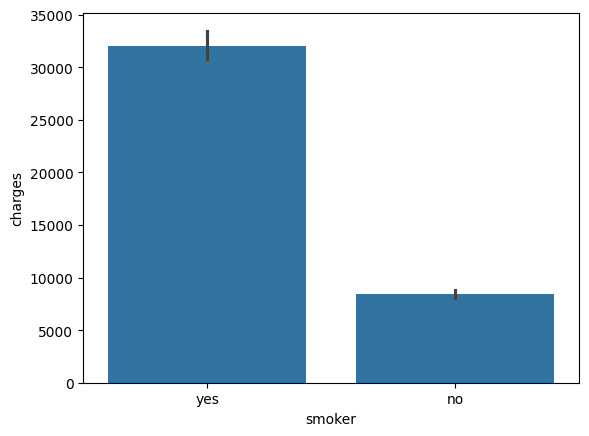

In [43]:
sns.barplot(data=medical_df, x='smoker', y='charges')
plt.show()

In [44]:
smoker_codes = {'no': 0, 'yes': 1}
# medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)
medical_df['smoker_code'] = medical_df['smoker'].map(smoker_codes)


In [45]:
medical_df['charges'].corr(medical_df['smoker_code'])

np.float64(0.7872514304984782)

In [46]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


We can now use the smoker_code column for (multiple) linear regression.

In [47]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


* The loss reduces from 11355 to 6056, by approx. 50%! This is an important lesson: **never ignore categorical data**.
* Let's try adding the "sex" column as well.



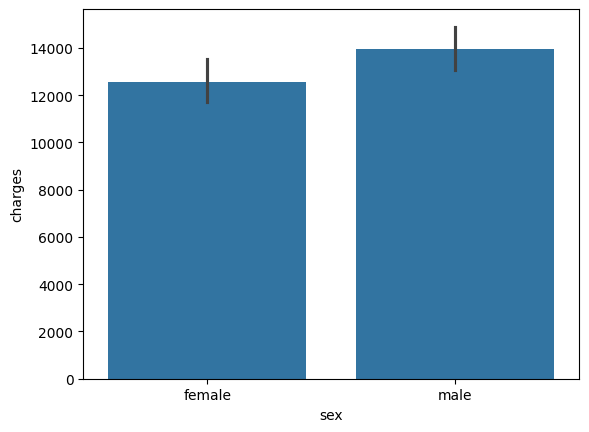

In [48]:
sns.barplot(data=medical_df, x='sex', y='charges')
plt.show()

In [49]:
sex_codes = {'female': 0, 'male': 1}
medical_df['sex_code'] = medical_df.sex.map(sex_codes)
medical_df['charges'].corr(medical_df['sex_code'])

np.float64(0.05729206220202531)

In [50]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


* As you might expect, this does not have a significant impact on the loss.

* Region

In [ ]:
sns.barplot(data=medical_df, x='region', y='charges')

In [ ]:
from sklearn import preprocessing

In [ ]:
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

In [ ]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

In [ ]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot

In [ ]:
medical_df.head()

* Let's include the region columns into our linear regression model

In [ ]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

* This leads to a fairly small reduction in the loss.

### Creating a test set

* Models like the one we've created in this tutorial are designed to be used in the real world

* It's common practice to set aside a small fraction of the data (e.g. 10%) just for testing and reporting the results of the model

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1) # 10%

In [ ]:
# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)

# Compute loss to evalute the model
loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)

* Let's compare this with the training loss.

In [ ]:
# Generate predictions
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

### Let's make a prediction for a single person based on our model

In [ ]:
john_smith = {
	"age": [30],             # Example age
    "bmi": [29.5],           # Example BMI
    "children": [2],         # Example number of children
    "smoker_code": [1],      # Smoker (1 for yes, 0 for no)
    "sex_code": [1],         # Male (1), Female (0)
    "northeast": [0],        # One-hot encoded region:
    "northwest": [1],
    "southeast": [0],
    "southwest": [0]
}

single_person = pd.DataFrame(john_smith)
single_person.head()

In [ ]:
single_prediction = model.predict(single_person)
print(f"Predicted health insurance charge for John Smith is {single_prediction[0]:.1f} USD")

* Prediction interval

In [ ]:
residuals = targets_train - predictions_train  # Compute residuals (errors)
std_dev = np.std(residuals)  # Compute the standard deviation of residuals
confidence_interval = 1.96 * std_dev  # Confidence interval (for 95% confidence level, 1.96 standard deviations)

# Make a single prediction
# single_prediction = model.predict(single_person)[0]

# Compute lower and upper bounds for prediction interval
lower_bound = single_prediction - confidence_interval
upper_bound = single_prediction + confidence_interval

print(f"Predicted value: {single_prediction}")
print(f"95% Prediction Interval: ({lower_bound}, {upper_bound})")

---

## In-class exercise

* Load the **Concrete data** dataset from this repository
* Run EDA (including visualisation)
* Run k-means clustering
* Run multiple linear regression to predict concrete **compressive strength** on test subset and individual input

---

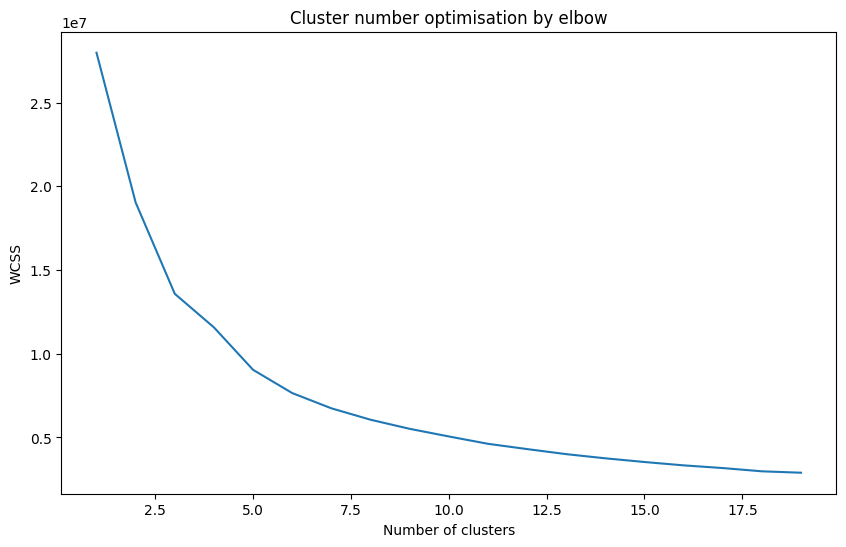

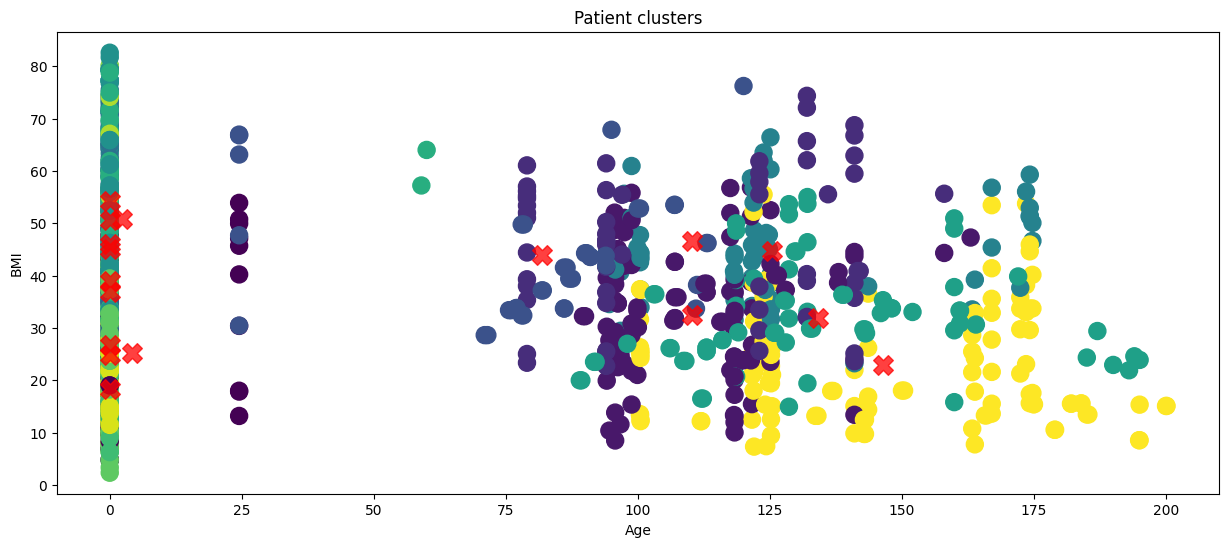

Predicted charge is: [55.55683311 55.55683311 44.47409456 ... 27.27390009 30.94826529
 35.45784373]
The loss is: 13.69


In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans

# Data path
data_path = '../datasets/concrete_data.csv'

# Load data
con_df = pd.read_csv(data_path)
con_df.head()
con_df.isna()
Y = con_df[['fly_ash', 'concrete_compressive_strength', 'cement', 'blast_furnace_slag', 'water', 'age' ]]  

wscc_con = []
for i in range(1, 20):
    kmean_con = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmean_con.fit(Y)
    wscc_con.append(kmean_con.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), wscc_con)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Cluster number optimisation by elbow")
plt.show()

# cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate ,age,concrete_compressive_strength
kmean_con = KMeans(n_clusters=17, init='k-means++', max_iter=300, n_init=15, random_state=42)

y_con_kmeans = kmean_con.fit_predict(Y)
con_df['Cluster'] = y_con_kmeans
con_df.head()

plt.figure(figsize=(15, 6))
plt.scatter(Y.iloc[:,0], Y.iloc[:,1], c=y_con_kmeans, s=150, cmap='viridis')  # review slicing through iterables; 0, 1 stands for columns
centers = kmean_con.cluster_centers_  # Retrieves coordinates of cluster centers
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, alpha=.75, marker='X')
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Patient clusters")
plt.show()

# Create inputs and targets:
inputs, targets = con_df[['cement', 'cement','blast_furnace_slag', ]], con_df['concrete_compressive_strength'] # affects of  both age and bmi on charges 

# Create and train the model:
model = LinearRegression().fit(inputs, targets)

# Run predictions:
predictions = model.predict(inputs)  # inputs [[22, 20]]
print(f"Predicted charge is: {predictions}")

# Compute loss to evaluate model:
loss = rmse(targets, predictions)
print(f"The loss is: {round(loss, 2)}")

##### Reminder: do not forget to **Clear All Outputs**
### Now you can commit and push your code to **GitHub**